In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split, cross_val_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import RandomizedSearchCV
import os
import shap
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        

/kaggle/input/datasets/rabieelkharoua/alzheimers-disease-dataset/alzheimers_disease_data.csv


## Problem Statement

Alzheimer’s disease is a neurodegenerative disorder associated with progressive decline in memory, cognition, and daily functioning. In this project, I use a public Alzheimer’s disease dataset to build an exploratory machine learning model that predicts whether a patient has an Alzheimer’s diagnosis.

The goal is not to create a clinically validated diagnostic tool. Instead, this notebook demonstrates a full biomedical machine learning workflow: loading the data, exploring key patterns, preprocessing features, training baseline and XGBoost models, evaluating performance, and interpreting which variables drive the predictions.

The target variable is Diagnosis, making this a binary classification problem: patients are classified as either having Alzheimer’s disease or not having Alzheimer’s disease.

## Dataset Overview
This section loads the Alzheimer’s disease dataset and reviews its structure, summary statistics, and available variables before modeling.

In [2]:
data = pd.read_csv("/kaggle/input/datasets/rabieelkharoua/alzheimers-disease-dataset/alzheimers_disease_data.csv")
data.describe()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
count,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,...,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000
mean,5825.000000,74.908795,0.506282,0.697534,1.286645,27.655697,0.288506,10.039442,4.920202,4.993138,...,5.080055,0.208004,0.156817,4.982958,0.205212,0.158213,0.150768,0.158678,0.301536,0.353653
std,620.507185,8.990221,0.500077,0.996128,0.904527,7.217438,0.453173,5.757910,2.857191,2.909055,...,2.892743,0.405974,0.363713,2.949775,0.403950,0.365026,0.357906,0.365461,0.459032,0.478214
min,4751.000000,60.000000,0.000000,0.000000,0.000000,15.008851,0.000000,0.002003,0.003616,0.009385,...,0.000460,0.000000,0.000000,0.001288,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5288.000000,67.000000,0.000000,0.000000,1.000000,21.611408,0.000000,5.139810,2.570626,2.458455,...,2.566281,0.000000,0.000000,2.342836,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5825.000000,75.000000,1.000000,0.000000,1.000000,27.823924,0.000000,9.934412,4.766424,5.076087,...,5.094439,0.000000,0.000000,5.038973,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6362.000000,83.000000,1.000000,1.000000,2.000000,33.869778,1.000000,15.157931,7.427899,7.558625,...,7.546981,0.000000,0.000000,7.581490,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,6899.000000,90.000000,1.000000,3.000000,3.000000,39.992767,1.000000,19.989293,9.987429,9.998346,...,9.996467,1.000000,1.000000,9.999747,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [3]:
data.columns

Index(['PatientID', 'Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI',
       'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality',
       'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease',
       'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP',
       'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
       'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment',
       'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion',
       'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks',
       'Forgetfulness', 'Diagnosis', 'DoctorInCharge'],
      dtype='object')

## Exploratory Data Analysis
This section checks the diagnosis distribution, missing values, and early clinical patterns. These steps help determine whether the dataset is balanced, whether preprocessing is needed, and which variables may be strongly related to diagnosis.

In [4]:
# Here, we check how many diagnosis there are
# and explore the dataset to understand diagnosis distribution, missing values, and key clinical patterns.
diagnosis_counts = data['Diagnosis'].value_counts()
print(diagnosis_counts)

Diagnosis
0    1389
1     760
Name: count, dtype: int64


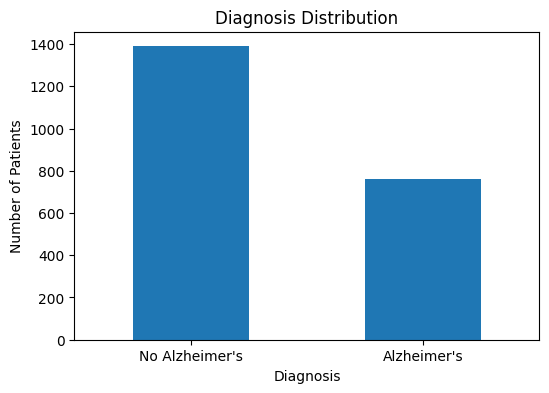

In [5]:
# Check how many patients are in each diagnosis group
diagnosis_counts = data["Diagnosis"].value_counts().sort_index()

# Rename 0 and 1 to clearer labels
label_map = {
    0: "No Alzheimer's",
    1: "Alzheimer's"
}

diagnosis_counts.index = diagnosis_counts.index.map(label_map)

# Create bar plot
plt.figure(figsize=(6, 4))
diagnosis_counts.plot(kind="bar")

plt.title("Diagnosis Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)

plt.show()

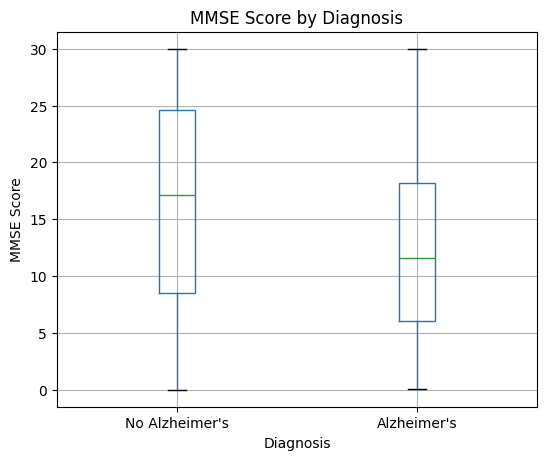

In [6]:
# Compare MMSE scores by diagnosis group
data.boxplot(column="MMSE", by="Diagnosis", figsize=(6, 5))

plt.title("MMSE Score by Diagnosis")
plt.suptitle("")
plt.xlabel("Diagnosis")
plt.ylabel("MMSE Score")
plt.xticks([1, 2], ["No Alzheimer's", "Alzheimer's"])

plt.show()

The MMSE boxplot compares cognitive scores between patients without Alzheimer’s disease and patients with Alzheimer’s disease. Patients without Alzheimer’s generally have higher MMSE scores, while patients with Alzheimer’s tend to have lower scores. This pattern is expected because MMSE measures cognitive function, and lower scores are associated with greater cognitive impairment.

The two groups still overlap, so MMSE alone does not perfectly separate Alzheimer’s and non-Alzheimer’s cases. Some patients with Alzheimer’s have relatively high MMSE scores, while some patients without Alzheimer’s have lower scores. This suggests that MMSE is an important predictor, but the model should still use multiple features rather than relying on one variable.

Because MMSE is closely tied to cognitive diagnosis, it should be interpreted carefully during the leakage investigation. A strong relationship with the target may improve model performance while also raising questions about whether the feature is acting as an independent predictor.

In [7]:
# Prepare the data by separating features and target, removing unnecessary columns, and creating train/test sets.
features = ['Age', 'Gender', 'EducationLevel', 'BMI',
       'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality',
       'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease',
       'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP',
       'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
       'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment',
       'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion',
       'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks',
       'Forgetfulness']
X = data[features]
y = data.Diagnosis

# Count missing values in each column
missing_values = data.isnull().sum()

# Keep only columns with missing values
missing_values = missing_values[missing_values > 0]

# Plot missing values if any exist
if len(missing_values) > 0:
    plt.figure(figsize=(10, 5))
    missing_values.sort_values(ascending=False).plot(kind="bar")
    plt.title("Missing Values by Column")
    plt.xlabel("Column")
    plt.ylabel("Number of Missing Values")
    plt.xticks(rotation=45, ha="right")
    plt.show()
else:
    print("No missing values found.")

# Break off validation set from training data
X_train_full, X_valid_full, y_train, y_valid = train_test_split(X, y, train_size=0.8, test_size=0.2, stratify = y, random_state=0)


categorical_cols = [cname for cname in X_train_full.columns if X_train_full[cname].nunique() < 10 and 
                        X_train_full[cname].dtype == "object"]

# Select numerical columns
numerical_cols = [cname for cname in X_train_full.columns if X_train_full[cname].dtype in ['int64', 'float64']]

# Keep selected columns only
my_cols = categorical_cols + numerical_cols
X_train = X_train_full[my_cols].copy()
X_valid = X_valid_full[my_cols].copy()

# Preprocessing for numerical data
numerical_transformer = SimpleImputer(strategy='constant')

# Preprocessing for categorical data
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Bundle preprocessing for numerical and categorical data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

No missing values found.


## Baseline Model: Random Forest
A Random Forest model provides a strong baseline before training XGBoost. This helps compare whether the more advanced boosting model meaningfully improves performance.

In [8]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=0
    ))
])

# Train the Random Forest model
rf_model.fit(X_train, y_train)

# Make predictions
rf_predictions = rf_model.predict(X_valid)
rf_probabilities = rf_model.predict_proba(X_valid)[:, 1]

# Evaluate the Random Forest model
print("Random Forest Accuracy:", accuracy_score(y_valid, rf_predictions))
print("Random Forest ROC-AUC:", roc_auc_score(y_valid, rf_probabilities))
print("\nClassification Report:")
print(classification_report(y_valid, rf_predictions))


Random Forest Accuracy: 0.9418604651162791
Random Forest ROC-AUC: 0.9456526883756154

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.96       278
           1       0.95      0.88      0.91       152

    accuracy                           0.94       430
   macro avg       0.94      0.93      0.94       430
weighted avg       0.94      0.94      0.94       430



The Random Forest baseline achieved approximately 94.2% accuracy and a ROC-AUC of approximately 0.946 on the validation set. This suggests that the model separated Alzheimer’s and non-Alzheimer’s cases well across classification thresholds.

For the No Alzheimer’s class, the model achieved high precision and recall, meaning it was especially strong at identifying patients without Alzheimer’s disease. For the Alzheimer’s class, precision was also high, but recall was lower, meaning the model still missed some true Alzheimer’s cases.

In a medical context, false negatives are especially important because they represent patients with Alzheimer’s disease who were not detected by the model. For that reason, accuracy alone is not enough. The model should also be evaluated using recall, ROC-AUC, the confusion matrix, and feature interpretation.

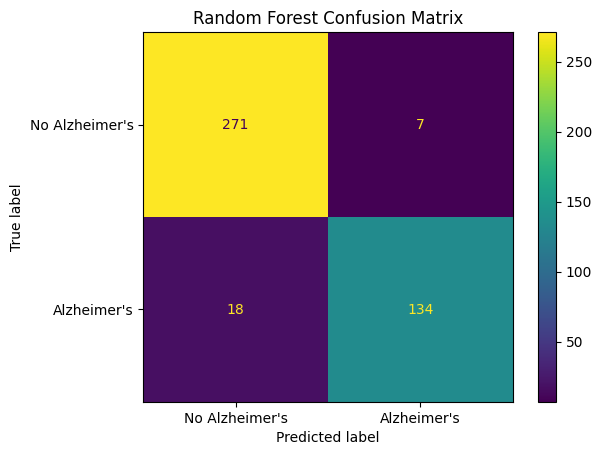

In [9]:
# Plot confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_valid,
    rf_predictions,
    display_labels=["No Alzheimer's", "Alzheimer's"]
)

plt.title("Random Forest Confusion Matrix")
plt.show()

The confusion matrix shows how the Random Forest model classified patients into No Alzheimer’s and Alzheimer’s groups. The model correctly predicted 271 patients without Alzheimer’s and 134 patients with Alzheimer’s. It made 7 false positive errors and 18 false negative errors.

Overall, the model correctly classified 405 out of 430 validation patients. However, the false negatives deserve attention because they represent Alzheimer’s cases that the model missed. This reinforces why recall is important in clinical machine learning.

## Main Model: XGBClassifier
XGBoost is used as the main model because gradient-boosted trees often perform well on structured tabular datasets. The model is trained inside the same preprocessing pipeline to keep the workflow consistent.

In [10]:
# Train an XGBoost classifier to predict Alzheimer’s diagnosis from the selected features.
my_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        random_state=0,
        n_estimators=500,
        learning_rate=0.1,
    ))

])
# Fitting the model
my_pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='constant'),
                                                  ['Age', 'Gender',
                                                   'EducationLevel', 'BMI',
                                                   'Smoking',
                                                   'AlcoholConsumption',
                                                   'PhysicalActivity',
                                                   'DietQuality',
                                                   'SleepQuality',
                                                   'FamilyHistoryAlzheimers',
                                                   'CardiovascularDisease',
                                                   'Diabetes', 'Depression',
                                                   'HeadInjury', 'Hypertension',
                                                   'SystolicBP', 'DiastolicB...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=500, n_jobs=None,
                               num_parallel_tree=None, ...))])

## Evaluation
The XGBoost model is evaluated using accuracy, ROC-AUC, a confusion matrix, and a classification report. These metrics give a fuller picture than accuracy alone.

In [11]:
# Evaluate model performance using accuracy, precision, recall, F1 score, ROC-AUC, and a confusion matrix.
xgb_probabilities = my_pipeline.predict_proba(X_valid)[:, 1]
prediction = my_pipeline.predict(X_valid)

print("Accuracy:", accuracy_score(y_valid, prediction))
print("XGB ROC-AUC:", roc_auc_score(y_valid, xgb_probabilities))
print(confusion_matrix(y_valid, prediction))
print(classification_report(y_valid, prediction))

Accuracy: 0.9488372093023256
XGB ROC-AUC: 0.9470607724346838
[[270   8]
 [ 14 138]]
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       278
           1       0.95      0.91      0.93       152

    accuracy                           0.95       430
   macro avg       0.95      0.94      0.94       430
weighted avg       0.95      0.95      0.95       430



The XGBoost model achieved approximately 94.9% accuracy on the validation set. It correctly classified 408 out of 430 patients, with 270 true negatives and 138 true positives. It made 8 false positive errors and 14 false negative errors.

The classification report shows strong performance for both classes. For the No Alzheimer’s class, the model achieved high precision and recall. For the Alzheimer’s class, recall was approximately 0.91, meaning the model detected most—but not all—true Alzheimer’s cases.

The ROC-AUC score of approximately 0.947 suggests that the model separates Alzheimer’s and non-Alzheimer’s cases well using predicted probabilities. However, because this is a medical classification problem, the false negatives should still be interpreted carefully.

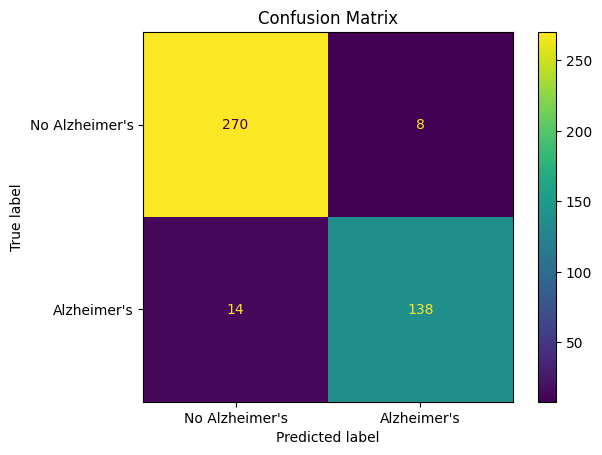

In [12]:
# Confusion matrix graph
cm = confusion_matrix(y_valid, prediction)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Alzheimer's", "Alzheimer's"])
disp.plot()

plt.title("Confusion Matrix")
plt.show()

The confusion matrix provides a clearer view of the XGBoost model’s errors. Class 0 represents No Alzheimer’s, and class 1 represents Alzheimer’s. The model correctly predicted 270 patients without Alzheimer’s and 138 patients with Alzheimer’s. It incorrectly labeled 8 non-Alzheimer’s cases as Alzheimer’s and missed 14 Alzheimer’s cases.

Overall, the model performed strongly, but the false negatives are clinically important. A high accuracy score is useful, but it does not fully capture the cost of missed Alzheimer’s cases.

## Overfitting Check
This section compares training accuracy with validation accuracy. A large gap between the two can suggest that the model is memorizing the training data instead of learning patterns that generalize.

In [13]:
train_preds = my_pipeline.predict(X_train)
valid_preds = my_pipeline.predict(X_valid)

print("Training Accuracy:", accuracy_score(y_train, train_preds))
print("Validation Accuracy:", accuracy_score(y_valid, valid_preds))

Training Accuracy: 1.0
Validation Accuracy: 0.9488372093023256


The model achieved 1.0 training accuracy and approximately 95.1% validation accuracy. This means the model performed perfectly on the training data but slightly worse on unseen validation data.

This gap suggests mild overfitting. However, the validation accuracy is still high, so the model is not failing to generalize completely. The next step is to interpret which features are driving the model’s predictions and check whether any of the strongest predictors may be too closely related to the diagnosis label.

## Hyperparameter Tuning

The model achieved 1.0 training accuracy and approximately 0.96 validation accuracy, suggesting mild overfitting. To reduce this gap, I used `RandomizedSearchCV` to test different XGBoost hyperparameter combinations.

I tuned parameters related to model complexity, regularization, and sampling, including `max_depth`, `n_estimators`, `learning_rate`, `subsample`, `colsample_bytree`, and `reg_lambda`. The search used ROC-AUC as the scoring metric to evaluate how well each model separated Alzheimer’s and non-Alzheimer’s cases.

In [14]:
param_grid = {
    'model__max_depth': [3, 4, 6],          # shallower trees = less overfitting
    'model__n_estimators': [100, 300, 500], # number of boosting rounds
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.7, 0.9, 1.0],        # row sampling to reduce overfitting
    'model__colsample_bytree': [0.7, 0.9, 1.0], # feature sampling to reduce overfitting
    'model__reg_lambda': [1, 5, 10]             # L2 regularization strength
}

base_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(random_state=0))
])

grid_search = RandomizedSearchCV(
    base_pipeline,
    param_grid,
    n_iter=40,          # number of random combinations to try (instead of all 729)
    cv=5,
    scoring='roc_auc',
    random_state=0,     
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV ROC-AUC:", grid_search.best_score_)

best_pipeline = grid_search.best_estimator_
best_preds = best_pipeline.predict(X_valid)
best_probs = best_pipeline.predict_proba(X_valid)[:, 1]

print("Validation Accuracy:", accuracy_score(y_valid, best_preds))
print("Validation ROC-AUC:", roc_auc_score(y_valid, best_probs))

# Check whether the overfitting gap has closed
train_preds_best = best_pipeline.predict(X_train)
print("Training Accuracy:", accuracy_score(y_train, train_preds_best))
print("Validation Accuracy:", accuracy_score(y_valid, best_preds))

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best params: {'model__subsample': 1.0, 'model__reg_lambda': 10, 'model__n_estimators': 500, 'model__max_depth': 6, 'model__learning_rate': 0.01, 'model__colsample_bytree': 1.0}
Best CV ROC-AUC: 0.9552067024833727
Validation Accuracy: 0.9511627906976744
Validation ROC-AUC: 0.9449308973873533
Training Accuracy: 0.9621873182082606
Validation Accuracy: 0.9511627906976744


In [15]:
# Cross-validated ROC-AUC
cv_scores = cross_val_score(
    my_pipeline,
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

print("Average Cross-Validated ROC-AUC:", cv_scores.mean())

Average Cross-Validated ROC-AUC: 0.9479634703789316


## Leakage Investigation

In [16]:
# Identify which features contributed most to the XGBoost model’s predictions.

xgb_model = best_pipeline.named_steps["model"]

feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
23,num__MemoryComplaints,0.214878
22,num__FunctionalAssessment,0.167707
24,num__BehavioralProblems,0.154681
25,num__ADL,0.130805
21,num__MMSE,0.129402
14,num__Hypertension,0.015502
0,num__Age,0.012073
18,num__CholesterolLDL,0.011826
2,num__EducationLevel,0.011379
19,num__CholesterolHDL,0.010937


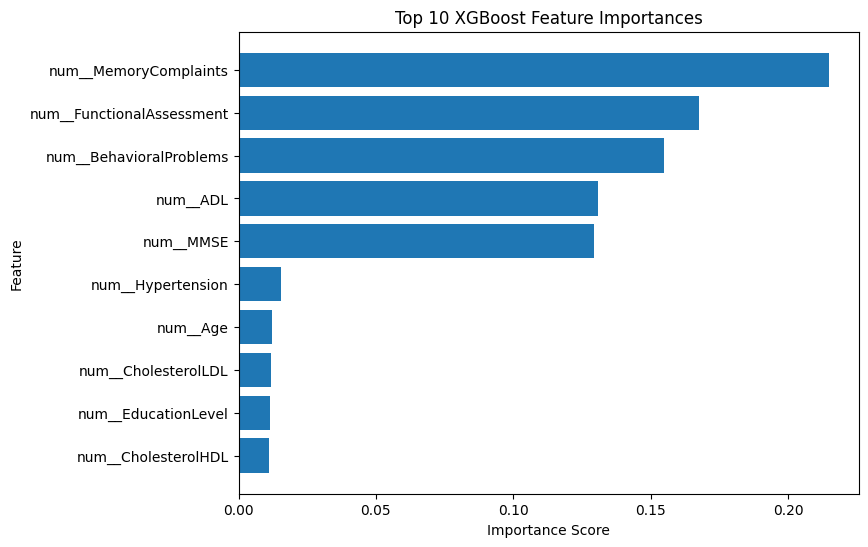

In [17]:
# Select top 10 most important features
top_features = feature_importance.head(10)

# Create horizontal bar plot
plt.figure(figsize=(8, 6))
plt.barh(top_features["Feature"], top_features["Importance"])

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 10 XGBoost Feature Importances")

# Make most important feature appear at the top
plt.gca().invert_yaxis()

plt.show()

The strongest predictors appear to be cognitive, functional, and behavioral assessment variables such as MMSE, FunctionalAssessment, MemoryComplaints, BehavioralProblems, and ADL. These features may be closely related to how the Diagnosis label was determined.

To test whether the model is learning broader risk patterns or mainly recovering diagnostic labels from assessment-based variables, I remove the suspected leakage features and retrain the model on the remaining demographic, lifestyle, and medical-history variables.

In [18]:
leakage_suspects = ['MMSE', 'FunctionalAssessment', 'MemoryComplaints',
                     'BehavioralProblems', 'ADL', 'Confusion',
                     'Disorientation', 'DifficultyCompletingTasks', 'Forgetfulness']

# Remove suspects to test whether remaining features have real predictive signal
features_no_leak = [f for f in features if f not in leakage_suspects]

X_nl = data[features_no_leak]
y_nl = data.Diagnosis

X_train_nl, X_valid_nl, y_train_nl, y_valid_nl = train_test_split(
    X_nl, y_nl, train_size=0.8, test_size=0.2, stratify=y_nl, random_state=0
)

# Rebuild a preprocessor for this smaller feature set
numerical_cols_nl = [c for c in X_train_nl.columns if X_train_nl[c].dtype in ['int64', 'float64']]
categorical_cols_nl = [c for c in X_train_nl.columns if X_train_nl[c].dtype == 'object']

preprocessor_nl = ColumnTransformer(transformers=[
    ('num', SimpleImputer(strategy='constant'), numerical_cols_nl),
    ('cat', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_cols_nl)
])

pipeline_nl = Pipeline(steps=[
    ('preprocessor', preprocessor_nl),
    ('model', XGBClassifier(random_state=0, n_estimators=500, learning_rate=0.1))
])

pipeline_nl.fit(X_train_nl, y_train_nl)
preds_nl = pipeline_nl.predict(X_valid_nl)
probs_nl = pipeline_nl.predict_proba(X_valid_nl)[:, 1]

print("Accuracy WITHOUT cognitive/functional features:", accuracy_score(y_valid_nl, preds_nl))
print("ROC-AUC WITHOUT cognitive/functional features:", roc_auc_score(y_valid_nl, probs_nl))
print(classification_report(y_valid_nl, preds_nl))

Accuracy WITHOUT cognitive/functional features: 0.586046511627907
ROC-AUC WITHOUT cognitive/functional features: 0.47531711472926924
              precision    recall  f1-score   support

           0       0.64      0.80      0.71       278
           1       0.35      0.19      0.25       152

    accuracy                           0.59       430
   macro avg       0.49      0.50      0.48       430
weighted avg       0.54      0.59      0.55       430



After removing the cognitive and functional assessment features, model performance dropped sharply. Accuracy fell to approximately 58.6%, and ROC-AUC dropped to approximately 0.48, which is near or below chance-level discrimination.

This is the most important finding in the notebook. The original model’s high performance appears to depend heavily on features that are closely tied to the diagnostic label. Therefore, the model is better understood as recovering diagnosis from correlated clinical assessments, not as predicting Alzheimer’s disease from independent upstream risk factors.

## SHAP Interpretability
SHAP is used to examine which features contributed most to the tuned XGBoost model’s predictions. This helps connect model performance to the leakage investigation.

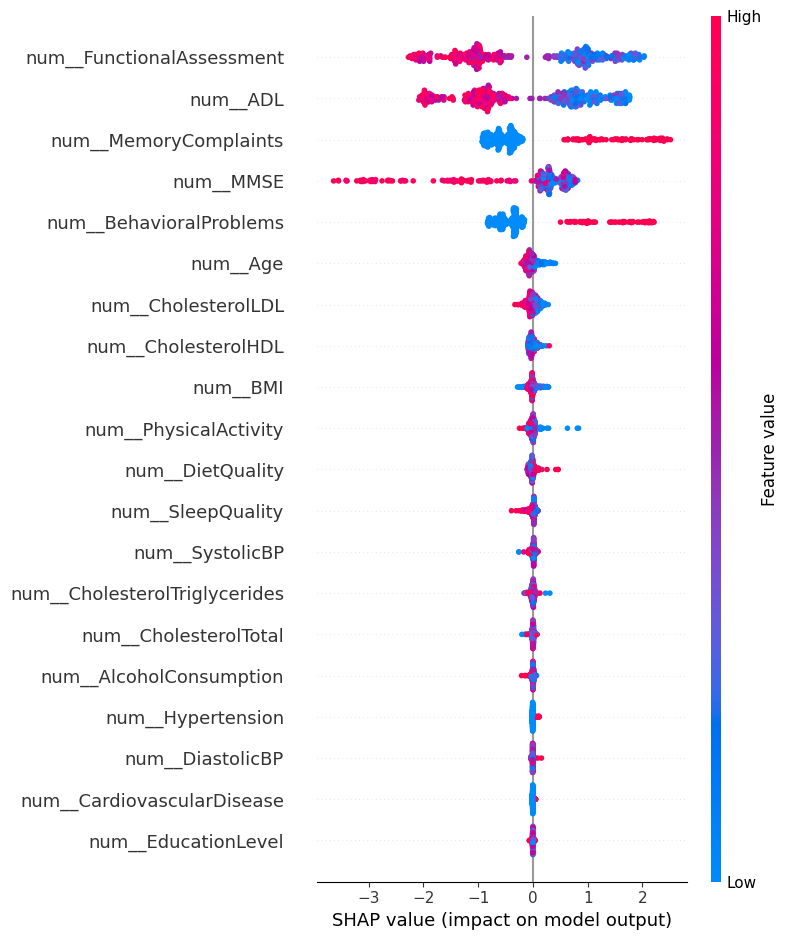

In [19]:
# Transform validation data through the preprocessor to get feature names
X_valid_transformed = best_pipeline.named_steps['preprocessor'].transform(X_valid)
feature_names = best_pipeline.named_steps['preprocessor'].get_feature_names_out()

explainer = shap.TreeExplainer(best_pipeline.named_steps['model'])
shap_values = explainer.shap_values(X_valid_transformed)

shap.summary_plot(shap_values, X_valid_transformed, feature_names=feature_names)

The SHAP summary plot shows which variables most strongly influenced the model’s predictions. Features near the top have the largest average impact. Positive SHAP values push predictions toward Alzheimer’s disease, while negative SHAP values push predictions toward No Alzheimer’s.

The most influential features were FunctionalAssessment, ADL, MemoryComplaints, MMSE, and BehavioralProblems. This means the model relied most heavily on cognitive, functional, and behavioral indicators rather than broader health variables such as cholesterol, BMI, blood pressure, smoking, or physical activity.

This improves interpretability because the strongest predictors are clinically meaningful. However, it also supports the leakage concern: several of the most important features are likely closely tied to the diagnosis process itself. As a result, the high validation performance should be interpreted cautiously.

## Limitations

This project is exploratory and should not be interpreted as a clinically validated diagnostic tool. The dataset is public and may not fully represent real-world clinical populations. The model was trained on tabular clinical and lifestyle features rather than MRI, PET, genetic, or biomarker data, so it cannot capture the full biological complexity of Alzheimer’s disease.

The main limitation is that model performance depends heavily on cognitive and functional assessment features, including MMSE, FunctionalAssessment, MemoryComplaints, BehavioralProblems, and ADL. When these features are removed, ROC-AUC drops to approximately 0.48, indicating that the remaining demographic, lifestyle, and general medical-history variables provide little independent predictive signal in this dataset.

This suggests that the original model is not necessarily predicting Alzheimer’s disease from upstream risk factors. Instead, it may be learning from variables that are closely related to, or possibly part of, the diagnostic criteria. Therefore, any claim that this is a predictive diagnostic model should be made carefully.

The initial XGBoost model also showed signs of overfitting, with 1.0 training accuracy and lower validation accuracy. Hyperparameter tuning reduced the training/validation gap while keeping validation performance similar, suggesting the validation results were fairly stable but still driven by the same high-signal assessment variables.

Future work should test the model on independent datasets, include neuroimaging or biomarker features, evaluate calibration, and study whether predictions remain useful when diagnostic-assessment variables are removed.

## Conclusion 
In this project, I built and evaluated machine learning models to classify Alzheimer’s disease diagnosis using demographic, lifestyle, medical-history, cognitive, and functional features. I trained a Random Forest baseline model, developed an XGBoost model, tuned hyperparameters, evaluated performance with multiple metrics, and used feature importance and SHAP to interpret the results.

The initial models achieved strong validation performance, with the XGBoost model reaching approximately 94.9% accuracy and a ROC-AUC of approximately 0.947. However, the leakage investigation showed that this performance was driven primarily by cognitive and functional assessment variables. When those variables were removed, performance dropped sharply.

Overall, this project demonstrates both the value and the risk of machine learning in clinical datasets. High accuracy can look impressive, but it must be interpreted alongside feature meaning, leakage risk, and clinical context. The strongest contribution of this notebook is showing how a high-performing model can still require careful validation before being considered clinically useful.

## What I Learned
This project taught me that strong machine learning performance does not automatically mean a model is clinically useful. In clinical ML, it is important to ask whether the model is learning independent predictors or simply using variables that overlap with the diagnostic label.

The most important part of this project was not maximizing accuracy. It was identifying why the model performed well, testing for leakage, and reframing the results honestly based on the evidence.